![Alt text](https://imgur.com/orZWHly.png=80)
source: @allison_horst https://github.com/allisonhorst/penguins

You have been asked to support a team of researchers who have been collecting data about penguins in Antartica! The data is available in csv-Format as `penguins.csv`

**Origin of this data** : Data were collected and made available by Dr. Kristen Gorman and the Palmer Station, Antarctica LTER, a member of the Long Term Ecological Research Network.

**The dataset consists of 5 columns.**

Column | Description
--- | ---
culmen_length_mm | culmen length (mm)
culmen_depth_mm | culmen depth (mm)
flipper_length_mm | flipper length (mm)
body_mass_g | body mass (g)
sex | penguin sex

Unfortunately, they have not been able to record the species of penguin, but they know that there are **at least three** species that are native to the region: **Adelie**, **Chinstrap**, and **Gentoo**.  Your task is to apply your data science skills to help them identify groups in the dataset!

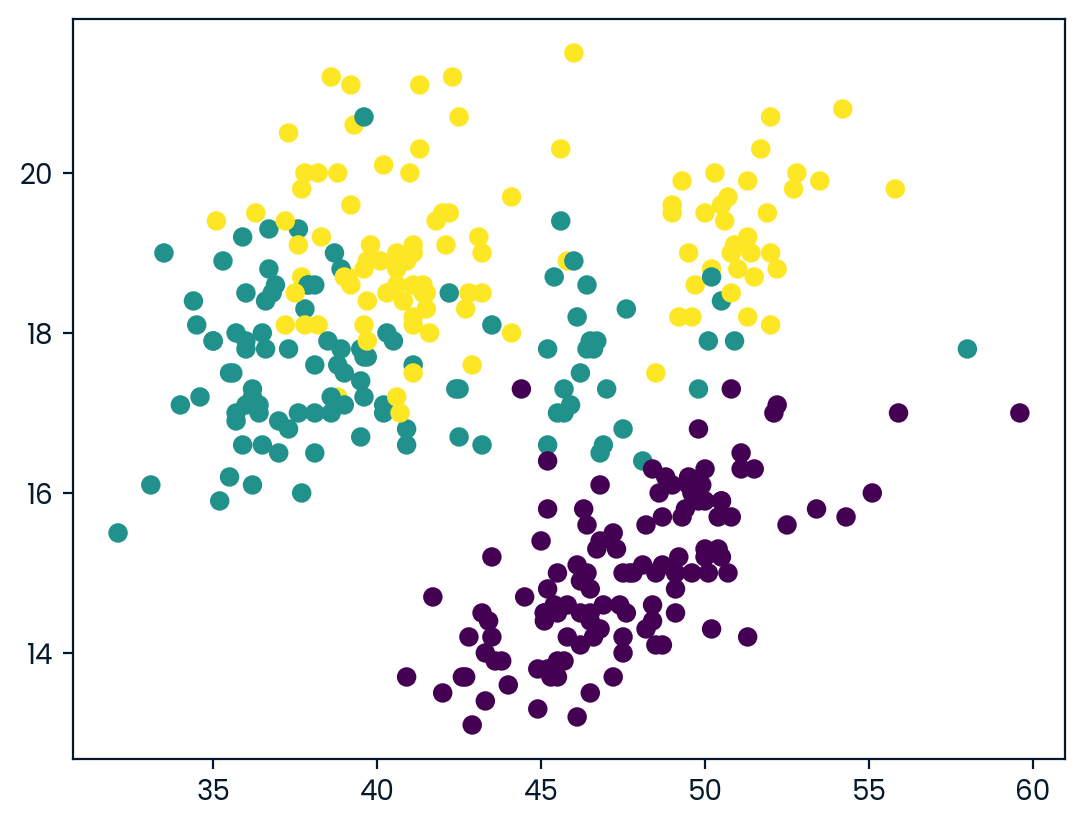

   culmen_length_mm  culmen_depth_mm  flipper_length_mm  body_mass_g
0         47.568067        14.996639         217.235294  5092.436975
1         40.217757        17.611215         189.046729  3419.158879
2         43.878302        19.111321         194.764151  4006.603774


In [6]:
# Import Required Packages
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Loading and examining the dataset
penguins_df = pd.read_csv("penguins.csv")
penguins_df.head()

penguins_df = pd.get_dummies(penguins_df)

scaler = StandardScaler()
kmeans = KMeans(n_clusters=3)
pipeline = make_pipeline(scaler,kmeans)

pipeline.fit(penguins_df)
labels = pipeline.predict(penguins_df)

plt.scatter(penguins_df["culmen_length_mm"],penguins_df["culmen_depth_mm"],c=labels)
plt.show()

centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_))
centroids.columns = penguins_df.columns
centroids.drop(["sex_FEMALE","sex_MALE"],axis=1,inplace=True)

stat_penguins = centroids
print(stat_penguins)
